In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
mlflow.set_experiment("warsaw-apartment-price")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print("MLflow ready. Run `mlflow ui` in the project root to browse runs.")

2026/06/03 21:09:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/03 21:09:36 INFO mlflow.store.db.utils: Updating database tables
2026/06/03 21:09:38 INFO mlflow.tracking.fluent: Experiment with name 'warsaw-apartment-price' does not exist. Creating a new experiment.


Tracking URI: sqlite:///C:/Users/lespa/OneDrive/Pulpit/real-estate-ml-system/notebooks/mlflow.db
MLflow ready. Run `mlflow ui` in the project root to browse runs.


In [3]:
df = pd.read_parquet('../data/processed/warsaw_apartments.parquet')
print(df.shape)
df.head()

(58065, 27)


,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,...,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,date,pricePerSqm
0,0,112.80,4.0,2.0,5.0,1998.0,52.236141,20.987732,1.19,73.0,...,1,0,1,1,1,0,0,2050000,6,18173.758865
1,1,54.64,2.0,4.0,5.0,1999.0,52.185400,20.959800,5.95,10.0,...,0,0,0,0,1,0,0,869000,6,15904.099561
2,1,60.00,3.0,NaN,5.0,2007.0,52.260800,21.058970,4.97,16.0,...,0,2,0,1,1,0,0,700000,6,11666.666667
3,1,28.80,2.0,9.0,11.0,1978.0,52.238200,20.908600,6.51,19.0,...,0,1,1,1,1,0,1,435000,6,15104.166667
4,0,122.70,5.0,3.0,3.0,1998.0,52.168100,21.079000,8.74,12.0,...,0,0,1,1,0,1,0,1500000,6,12224.938875


## Train / Test Split

In [4]:
X = df.drop(columns=['price', 'pricePerSqm'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (46452, 25), Test: (11613, 25)


## Baseline Model Comparison

In [5]:
baseline_models = {
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_estimators=500, learning_rate=0.05),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_estimators=500, learning_rate=0.05, tree_method='hist'),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
    'Ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', Ridge())
    ])
}

results = []
for name, model in baseline_models.items():
    with mlflow.start_run(run_name=f"baseline-{name.lower()}"):
        mlflow.set_tag("phase", "baseline")
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        mlflow.log_metrics({"rmse": rmse, "mape": round(mape * 100, 2)})
        results.append({'Model': name, 'RMSE': rmse, 'MAPE (%)': round(mape * 100, 2), 'Tuned': False})
        print(f"  RMSE: {rmse:,.0f} PLN | MAPE: {mape*100:.2f}%")

pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3168
[LightGBM] [Info] Number of data points in the train set: 46452, number of used features: 25
[LightGBM] [Info] Start training from score 1019529.321063
  RMSE: 113,764 PLN | MAPE: 8.12%
Training XGBoost...
  RMSE: 109,131 PLN | MAPE: 7.71%
Training RandomForest...
  RMSE: 80,242 PLN | MAPE: 4.55%
Training Ridge...
  RMSE: 209,079 PLN | MAPE: 14.86%


,Model,RMSE,MAPE (%),Tuned
0,RandomForest,80241.854805,4.55,False
1,XGBoost,109130.679688,7.71,False
2,LightGBM,113764.034411,8.12,False
3,Ridge,209079.476215,14.86,False


## Feature Importance (Random Forest baseline)

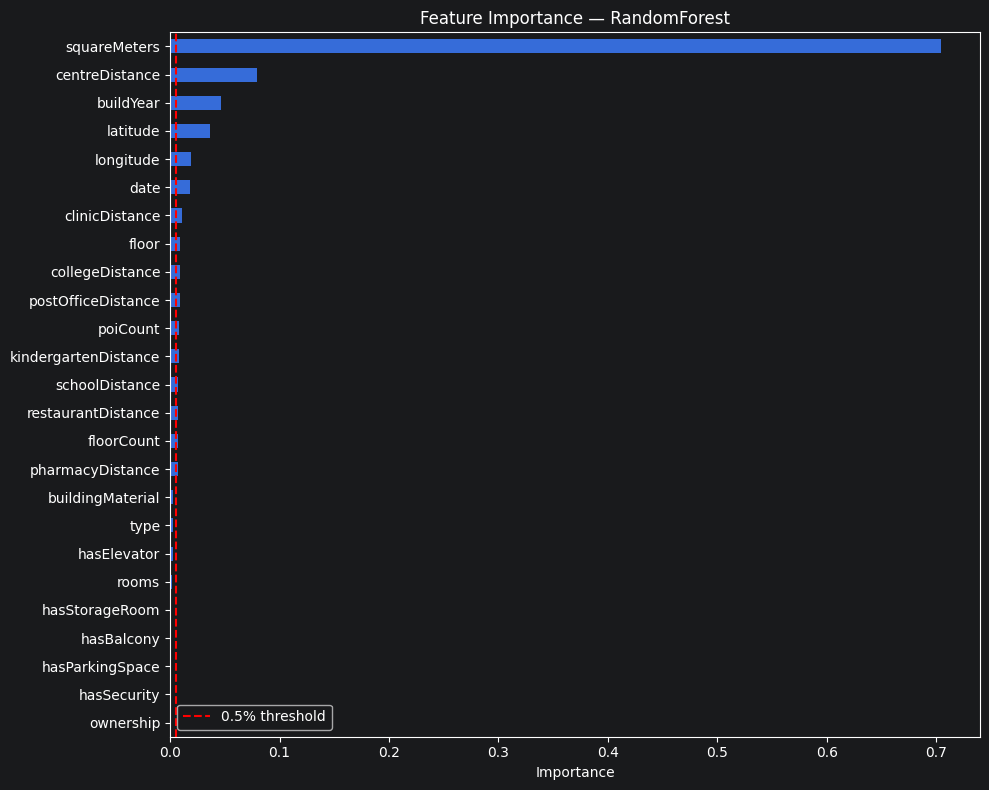


Features below 0.5% importance (candidates to drop):
['ownership', 'hasSecurity', 'hasParkingSpace', 'hasBalcony', 'hasStorageRoom', 'rooms', 'hasElevator', 'type', 'buildingMaterial']


In [6]:
importance = pd.Series(
    baseline_models['RandomForest'].feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.plot(kind='barh')
plt.title('Feature Importance \u2014 RandomForest')
plt.xlabel('Importance')
plt.axvline(x=0.005, color='red', linestyle='--', label='0.5% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\nFeatures below 0.5% importance (candidates to drop):")
print(importance[importance < 0.005].sort_values().index.tolist())

## Drop Low-Importance Features

In [7]:
low_importance = importance[importance < 0.005].index.tolist()
print(f"Dropping: {low_importance}")

X_train = X_train.drop(columns=low_importance)
X_test = X_test.drop(columns=low_importance)
print(f"Features remaining: {X_train.shape[1]}")

Dropping: ['ownership', 'hasSecurity', 'hasParkingSpace', 'hasBalcony', 'hasStorageRoom', 'rooms', 'hasElevator', 'type', 'buildingMaterial']
Features remaining: 16


## Optuna Tuning \u2014 LightGBM

In [8]:
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return root_mean_squared_error(y_test, y_pred)

lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=50)

with mlflow.start_run(run_name="optuna-lgb-best"):
    mlflow.set_tag("phase", "tuning")
    mlflow.log_params(lgb_study.best_params)
    mlflow.log_metric("rmse", lgb_study.best_value)

print(f"Best RMSE: {lgb_study.best_value:,.0f} PLN")
print(f"Best params: {lgb_study.best_params}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3141
[LightGBM] [Info] Number of data points in the train set: 46452, number of used features: 16
[LightGBM] [Info] Start training from score 1019529.321063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

## Optuna Tuning \u2014 XGBoost

In [9]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'tree_method': 'hist',
        'random_state': 42
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return root_mean_squared_error(y_test, y_pred)

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=50)

with mlflow.start_run(run_name="optuna-xgb-best"):
    mlflow.set_tag("phase", "tuning")
    mlflow.log_params(xgb_study.best_params)
    mlflow.log_metric("rmse", xgb_study.best_value)

print(f"Best RMSE: {xgb_study.best_value:,.0f} PLN")
print(f"Best params: {xgb_study.best_params}")

Best RMSE: 70,983 PLN
Best params: {'n_estimators': 893, 'learning_rate': 0.027596322430949068, 'max_depth': 12, 'min_child_weight': 3, 'subsample': 0.832038115259674, 'colsample_bytree': 0.903719694159528}


## Final Comparison

In [10]:
tuned_lgb = lgb.LGBMRegressor(**lgb_study.best_params, random_state=42, verbose=-1)
tuned_lgb.fit(X_train, y_train)
lgb_pred = tuned_lgb.predict(X_test)

tuned_xgb = xgb.XGBRegressor(**xgb_study.best_params, random_state=42)
tuned_xgb.fit(X_train, y_train)
xgb_pred = tuned_xgb.predict(X_test)

rf = RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

final_results = [
    {'Model': 'LightGBM (tuned)', 'RMSE': root_mean_squared_error(y_test, lgb_pred), 'MAPE (%)': round(mean_absolute_percentage_error(y_test, lgb_pred) * 100, 2)},
    {'Model': 'XGBoost (tuned)',  'RMSE': root_mean_squared_error(y_test, xgb_pred), 'MAPE (%)': round(mean_absolute_percentage_error(y_test, xgb_pred) * 100, 2)},
    {'Model': 'RandomForest (reduced features)', 'RMSE': root_mean_squared_error(y_test, rf_pred), 'MAPE (%)': round(mean_absolute_percentage_error(y_test, rf_pred) * 100, 2)},
]

with mlflow.start_run(run_name="final-lgb"):
    mlflow.set_tag("phase", "final")
    mlflow.log_params({**lgb_study.best_params, "random_state": 42})
    mlflow.log_metrics({"rmse": root_mean_squared_error(y_test, lgb_pred), "mape": round(mean_absolute_percentage_error(y_test, lgb_pred) * 100, 2)})
    mlflow.lightgbm.log_model(tuned_lgb, artifact_path="model")

with mlflow.start_run(run_name="final-xgb"):
    mlflow.set_tag("phase", "final")
    mlflow.log_params({**xgb_study.best_params, "random_state": 42})
    mlflow.log_metrics({"rmse": root_mean_squared_error(y_test, xgb_pred), "mape": round(mean_absolute_percentage_error(y_test, xgb_pred) * 100, 2)})
    mlflow.xgboost.log_model(tuned_xgb, artifact_path="model")

with mlflow.start_run(run_name="final-rf"):
    mlflow.set_tag("phase", "final")
    mlflow.log_params({"n_estimators": 200, "random_state": 42})
    mlflow.log_metrics({"rmse": root_mean_squared_error(y_test, rf_pred), "mape": round(mean_absolute_percentage_error(y_test, rf_pred) * 100, 2)})
    mlflow.sklearn.log_model(rf, artifact_path="model")

final_df = pd.DataFrame(final_results).sort_values('RMSE').reset_index(drop=True)
final_df

2026/06/03 21:41:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 21:41:01 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 21:41:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 21:41:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 21:41:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe al

,Model,RMSE,MAPE (%)
0,XGBoost (tuned),70983.429688,4.10
1,LightGBM (tuned),76193.343735,4.72
2,RandomForest (reduced features),81120.515784,4.58


In [11]:
import joblib
import json

joblib.dump(tuned_xgb, '../models/xgboost_model.joblib')

with open('../models/feature_names.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print("Saved model to models/xgboost_model.joblib")
print(f"Features: {list(X_train.columns)}")

Saved model to models/xgboost_model.joblib
Features: ['squareMeters', 'floor', 'floorCount', 'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance', 'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance', 'collegeDistance', 'pharmacyDistance', 'date']
